Step 0: Setup Corpus

In [ ]:
corpus = [
    "bank loan credit finance money",
    "river bank water flow stream",
    "loan approval bank credit risk",
    "river water bank erosion flood",
    "finance money investment bank",
    "stream river water nature bank"
]

Step 1: Convert Words into Embeddings

- We will use Word2Vec (Gensim) to generate embeddings.
- Word embeddings convert words → numerical vectors.
- Words with similar meanings have similar vectors.
- Example:
"bank" (finance) ≠ "bank" (river) → context matters.

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.3 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

# Tokenize corpus
tokenized_corpus = [sentence.split() for sentence in corpus]

# Train Word2Vec model
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4
)

# Get embedding of a word
print(model.wv['bank'])

[-1.0724545e-03  4.7286271e-04  1.0206699e-02  1.8018546e-02
 -1.8605899e-02 -1.4233618e-02  1.2917745e-02  1.7945977e-02
 -1.0030856e-02 -7.5267432e-03  1.4761009e-02 -3.0669428e-03
 -9.0732267e-03  1.3108104e-02 -9.7203208e-03 -3.6320353e-03
  5.7531595e-03  1.9837476e-03 -1.6570430e-02 -1.8897636e-02
  1.4623532e-02  1.0140524e-02  1.3515387e-02  1.5257311e-03
  1.2701781e-02 -6.8107317e-03 -1.8928028e-03  1.1537147e-02
 -1.5043275e-02 -7.8722071e-03 -1.5023164e-02 -1.8600845e-03
  1.9076237e-02 -1.4638334e-02 -4.6675373e-03 -3.8754821e-03
  1.6154874e-02 -1.1861792e-02  9.0324880e-05 -9.5074680e-03
 -1.9207101e-02  1.0014586e-02 -1.7519170e-02 -8.7836506e-03
 -7.0199967e-05 -5.9236289e-04 -1.5322480e-02  1.9229487e-02
  9.9641159e-03  1.8466286e-02]


Step 2: Store in Vector Database

We’ll simulate a vector DB using a dictionary (in real-world: FAISS, Pinecone).

In [ ]:
# Create vector database (word -> embedding)
vector_db = {}

for word in model.wv.index_to_key:
    vector_db[word] = model.wv[word]

print(vector_db.keys())

dict_keys(['bank', 'water', 'river', 'stream', 'money', 'finance', 'credit', 'loan', 'nature', 'investment', 'flood', 'erosion', 'risk', 'approval', 'flow'])


Step 3: Query → Find 4 Closest Words

- We use cosine similarity.
- Measures similarity between vectors.
- Value range: -1 to 1
- Higher = more similar

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_top_k_similar(query_word, k=4):
    query_vec = model.wv[query_word].reshape(1, -1)

    similarities = []

    for word, vec in vector_db.items():
        vec = vec.reshape(1, -1)
        sim = cosine_similarity(query_vec, vec)[0][0]
        similarities.append((word, sim))

    # Sort by similarity
    similarities = sorted(similarities, key=lambda x: x[1], reverse=True)

    return similarities[1:k+1]  # skip itself

# Example
print(get_top_k_similar("water"))

[('money', np.float32(0.12486254)), ('risk', np.float32(0.08061249)), ('credit', np.float32(0.073995754)), ('bank', np.float32(0.042373024))]


Step 4: Plot Embeddings (2D Visualization)

We reduce dimensions using PCA.

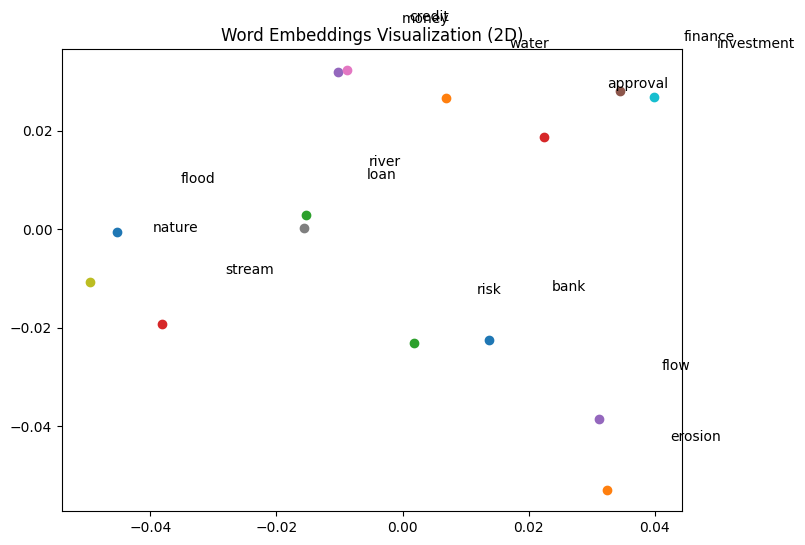

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = list(vector_db.keys())
embeddings = np.array([vector_db[word] for word in words])

# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embeddings Visualization (2D)")
plt.show()

For 4D Visualization:
- Not directly plottable, but you can:
     - Print vectors
    - Use pair plots
- reduce 4D → 2D again

In [ ]:
get_top_k_similar("money")

[('river', np.float32(0.16562691)),
 ('approval', np.float32(0.15375377)),
 ('loan', np.float32(0.13661063)),
 ('water', np.float32(0.12486254))]